In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
sales = pd.read_parquet("D:\Sample Projects\PulseBoard\data\clean/clean_sales.parquet")

sales["date"] = pd.to_datetime(sales["date"])

sales["revenue"] = (
    sales["units"]
    * sales["unit_price"]
    * (1 - sales["discount_pct"]/100)
)

sales["profit"] = (
    sales["revenue"]
    - sales["cost_price"] * sales["units"]
)

In [3]:
monthly = (

    sales

    .groupby(

        [

            pd.Grouper(

                key="date",

                freq="M"

            ),

            "region"

        ]

    )["revenue"]

    .sum()

    .reset_index()

)

In [4]:
monthly["rolling"] = (

    monthly

    .groupby("region")["revenue"]

    .transform(

        lambda x:

        x.rolling(3).mean()

    )

)

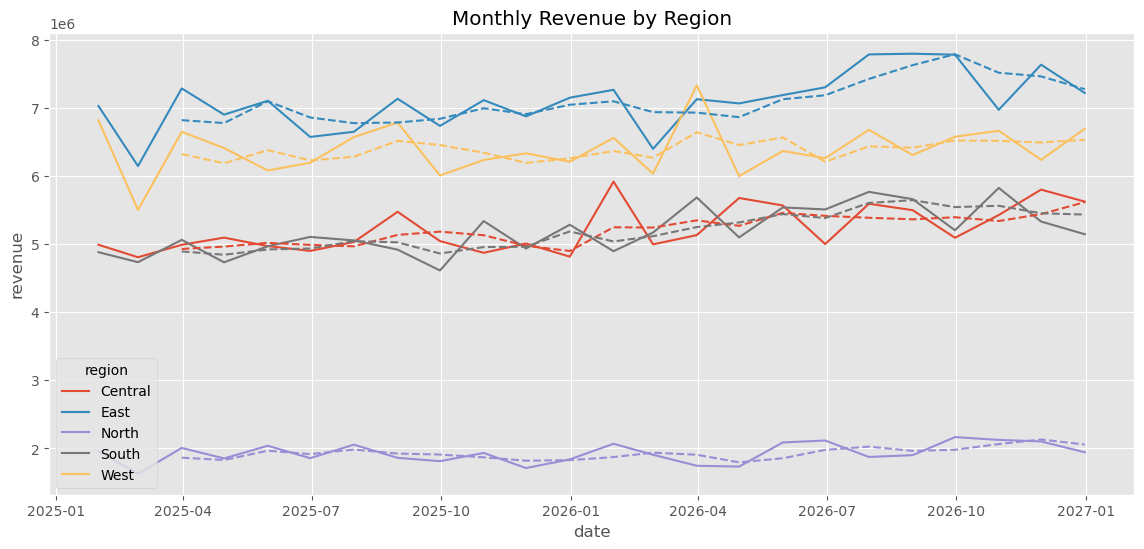

In [5]:
plt.figure(figsize=(14,6))

sns.lineplot(

    data=monthly,

    x="date",

    y="revenue",

    hue="region"

)

sns.lineplot(

    data=monthly,

    x="date",

    y="rolling",

    hue="region",

    legend=False,

    linestyle="--"

)

plt.title("Monthly Revenue by Region")

plt.show()

In [6]:
trend = (

    monthly

    .groupby("region")

    .apply(

        lambda x:

        (

            x.iloc[-1]["revenue"]

            -

            x.iloc[0]["revenue"]

        )

        /

        x.iloc[0]["revenue"]

        *100

    )

)

print(trend.sort_values())

region
West       -1.806949
North      -0.642386
East        2.712402
South       5.398736
Central    12.684853
dtype: float64


In [7]:
daily = (

    sales

    .groupby(

        "date"

    )["footfall"]

    .sum()

    .reset_index()

)

In [8]:
print(sales.columns)

Index(['transaction_id', 'date', 'store_id', 'product_id', 'units',
       'unit_price', 'discount_pct', 'payment_type', 'currency', 'region',
       'city', 'opened_date', 'sqft', 'category', 'sub_category', 'cost_price',
       'launch_date', 'return_date', 'reason', 'footfall', 'revenue',
       'profit'],
      dtype='object')


In [9]:
daily["weekday"] = daily["date"].dt.day_name()

daily["month"] = daily["date"].dt.month_name()

In [10]:
weekly = (

    daily

    .groupby("weekday")["footfall"]

    .mean()

)

In [11]:
monthly = (

    daily

    .groupby("month")["footfall"]

    .mean()

)

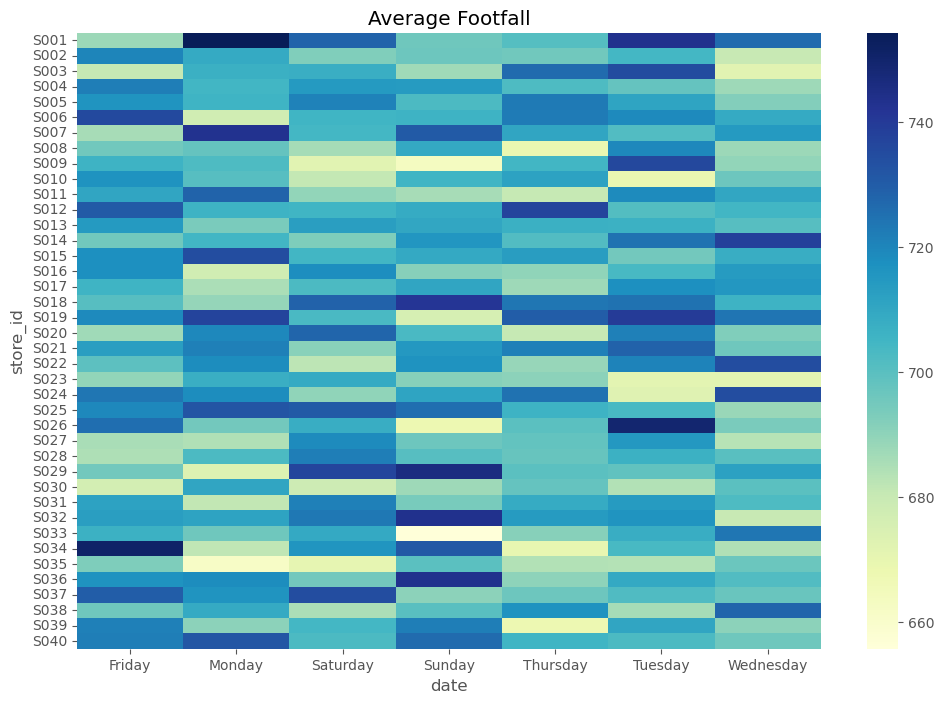

In [12]:
heat = (

    sales

    .groupby(

        [

            "store_id",

            sales["date"].dt.day_name()

        ]

    )["footfall"]

    .mean()

    .unstack()

)

plt.figure(figsize=(12,8))

sns.heatmap(

    heat,

    cmap="YlGnBu"

)

plt.title("Average Footfall")

plt.show()

In [13]:
daily = (

    sales

    .groupby(

        ["date","store_id"]

    )["revenue"]

    .sum()

    .reset_index()

)

In [14]:
store = daily[daily.store_id=="S001"].copy()

In [15]:
store["rolling"] = (

    store["revenue"]

    .rolling(30)

    .mean()

)

store["std"] = (

    store["revenue"]

    .rolling(30)

    .std()

)

In [16]:
store["anomaly"] = np.where(

    np.abs(

        store["revenue"]

        -

        store["rolling"]

    )

    >

    3*store["std"],

    True,

    False

)

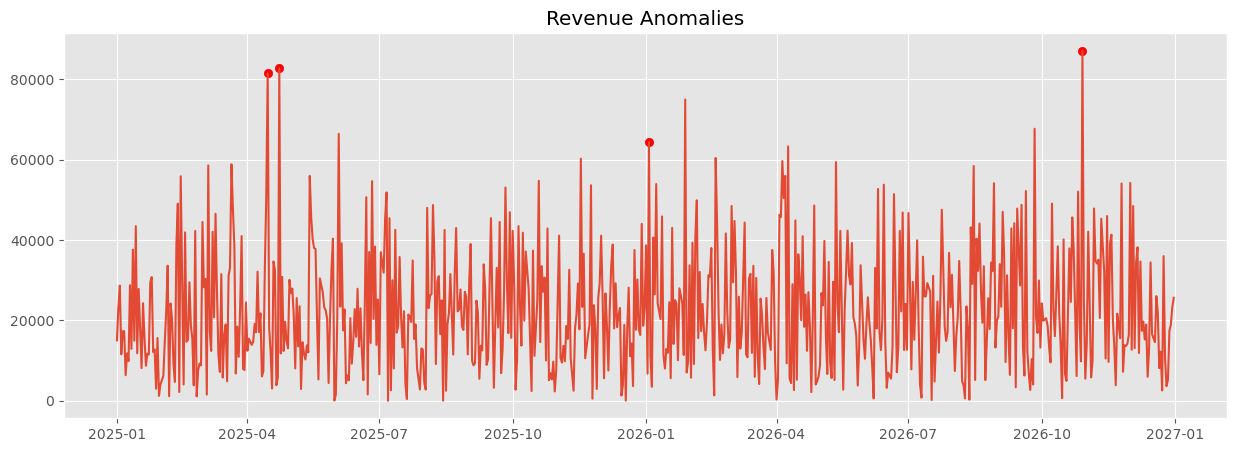

In [17]:
plt.figure(figsize=(15,5))

plt.plot(

    store["date"],

    store["revenue"]

)

plt.scatter(

    store.loc[store.anomaly,"date"],

    store.loc[store.anomaly,"revenue"],

    color="red"

)

plt.title("Revenue Anomalies")

plt.show()

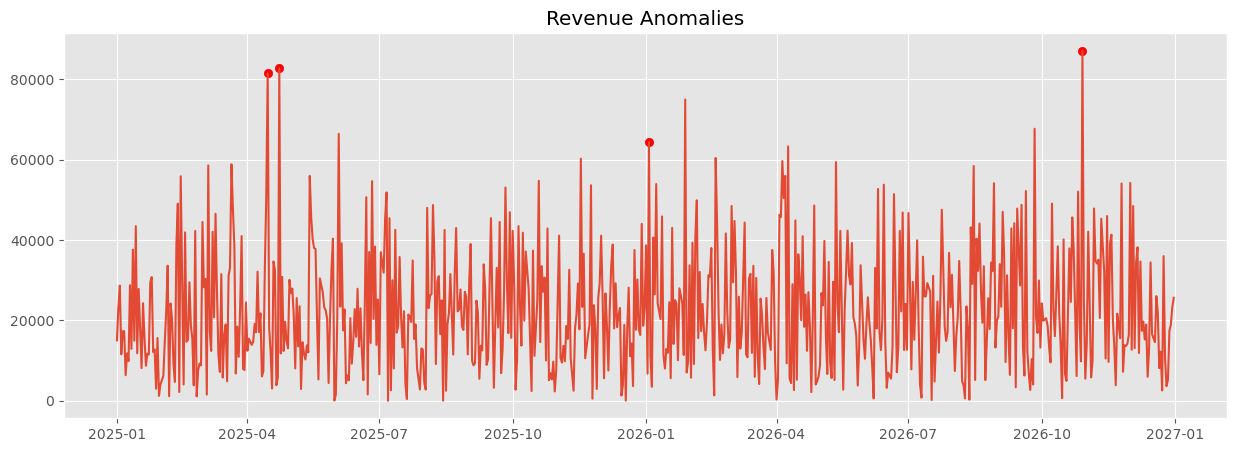

In [18]:
plt.figure(figsize=(15,5))

plt.plot(

    store["date"],

    store["revenue"]

)

plt.scatter(

    store.loc[store.anomaly,"date"],

    store.loc[store.anomaly,"revenue"],

    color="red"

)

plt.title("Revenue Anomalies")

plt.show()

In [19]:
profit = (

    sales

    .groupby("product_id")["profit"]

    .sum()

    .sort_values(

        ascending=False

    )

)

In [20]:
cum = (

    profit.cumsum()

    /

    profit.sum()

)

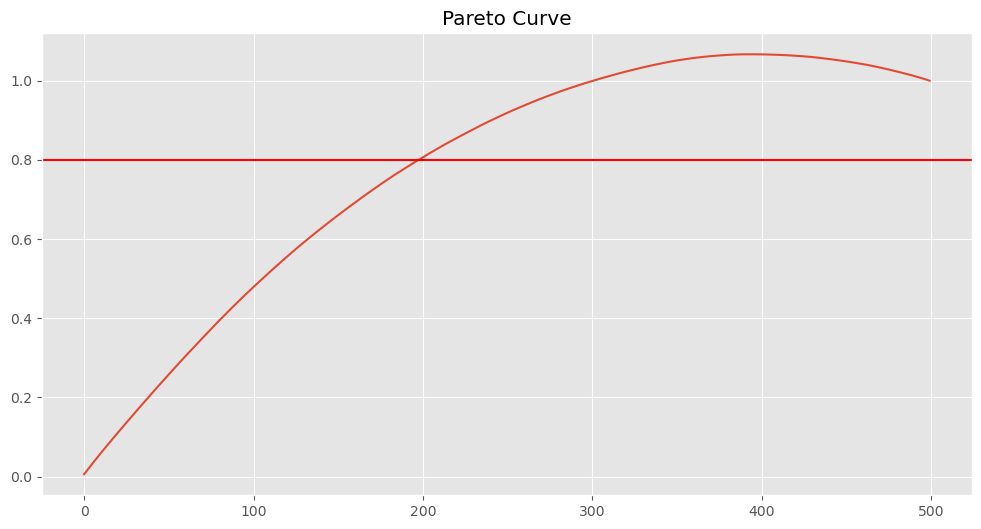

In [21]:
plt.figure(figsize=(12,6))

plt.plot(cum.values)

plt.axhline(

    0.8,

    color="red"

)

plt.title("Pareto Curve")

plt.show()

In [22]:
percent = (

    (cum<=0.8)

    .sum()

    /

    len(cum)

)*100

print(percent)

39.6


In [23]:
top = (

    sales

    .groupby("store_id")["revenue"]

    .sum()

    .nlargest(3)

    .index

)

In [24]:
for s in top:

    temp = (

        sales

        [sales.store_id==s]

        .groupby("date")

        [["footfall","revenue"]]

        .sum()

    )

    print(s)

    for lag in range(-7,8):

        corr = temp["footfall"].corr(

            temp["revenue"].shift(lag)

        )

        print(lag,corr)

S036
-7 0.003888188421822312
-6 0.024084285341776635
-5 -0.03293157749438753
-4 -0.05429816413550504
-3 -0.012666774094253574
-2 0.010538655158305838
-1 0.045071795480830394
0 0.6669258424898328
1 0.004153395028852006
2 0.006428193242502903
3 0.02482241519116138
4 -0.06975947096334402
5 0.055195936672720644
6 0.0663521571785278
7 0.07663581357922526
S025
-7 0.06280072993802942
-6 0.039638758205865474
-5 -0.03711660496285102
-4 0.08662582437210367
-3 -0.029104463886062196
-2 0.02287620114542494
-1 0.02267577812294936
0 0.662927667327016
1 0.053374594122738345
2 0.003945601300388686
3 -0.06944445730706349
4 -0.010251373292592526
5 -0.04291348844715347
6 0.027881324114264208
7 0.03305144824366327
S002
-7 -0.03487888717699276
-6 -0.07816148684541666
-5 0.0985815738023881
-4 -0.015990765331857962
-3 -0.03655790391880108
-2 -0.04728485598454782
-1 -0.02484859433171817
0 0.6895992156181022
1 0.009341285430864382
2 0.03708401081832221
3 -0.040163700815946016
4 -0.0016016503997436005
5 0.012496

In [25]:
sales["returned"] = (

    sales["return_date"]

    .notna()

)

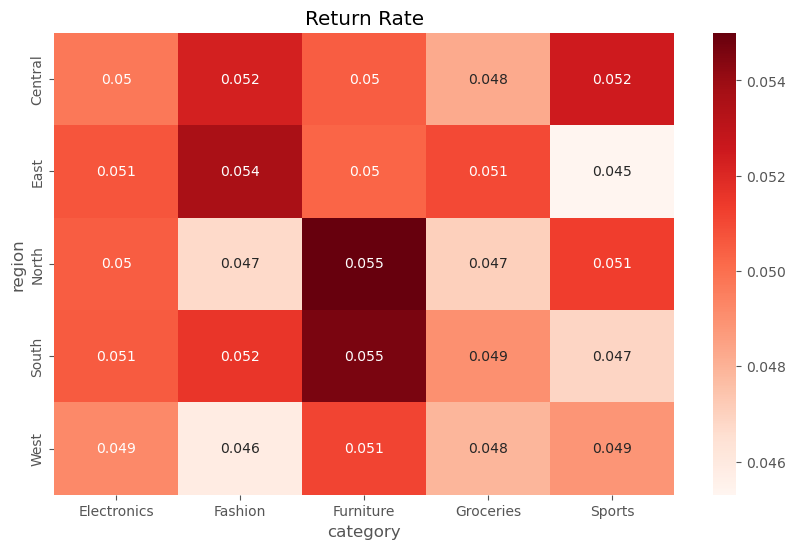

In [26]:
risk = (

    sales

    .groupby(

        [

            "region",

            "category"

        ]

    )["returned"]

    .mean()

    .unstack()

)

plt.figure(figsize=(10,6))

sns.heatmap(

    risk,

    annot=True,

    cmap="Reds"

)

plt.title("Return Rate")

plt.show()

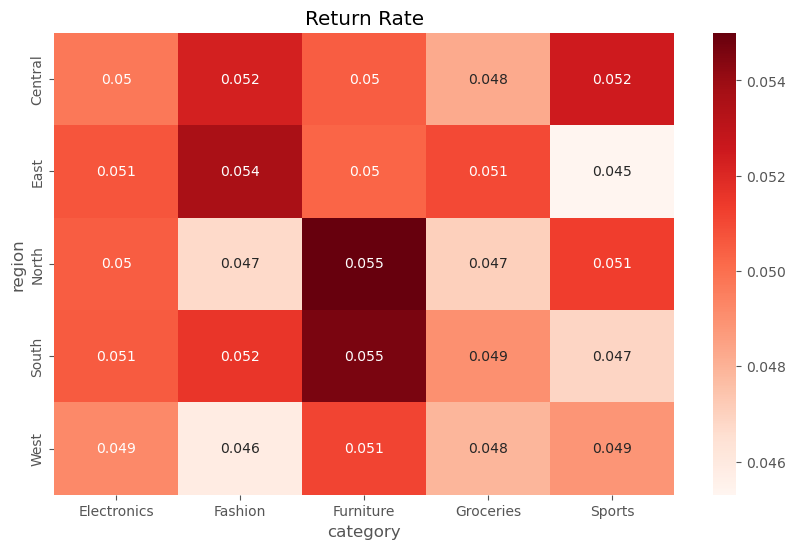

In [27]:
risk = (

    sales

    .groupby(

        [

            "region",

            "category"

        ]

    )["returned"]

    .mean()

    .unstack()

)

plt.figure(figsize=(10,6))

sns.heatmap(

    risk,

    annot=True,

    cmap="Reds"

)

plt.title("Return Rate")

plt.show()

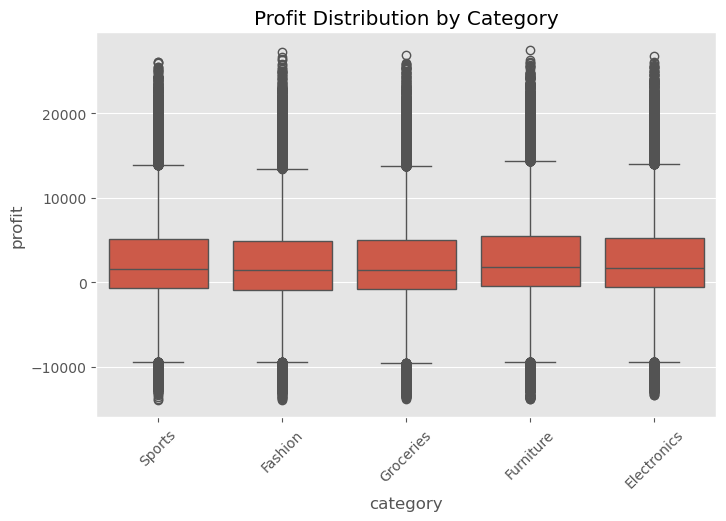

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=sales,
    x="category",
    y="profit"
)

plt.title("Profit Distribution by Category")
plt.xticks(rotation=45)
plt.show()

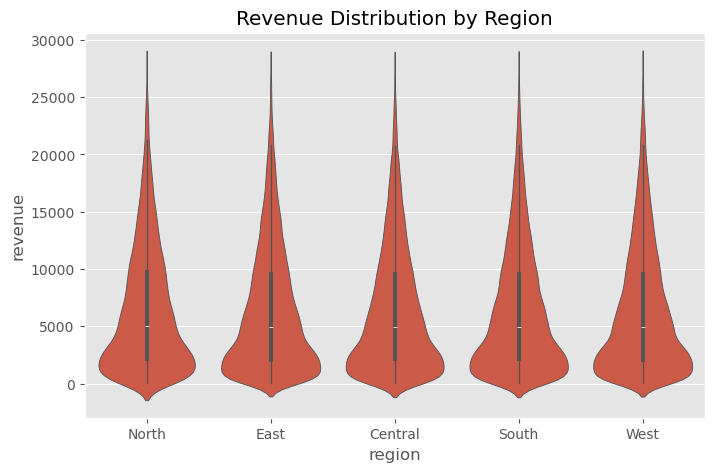

In [29]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=sales,
    x="region",
    y="revenue"
)

plt.title("Revenue Distribution by Region")
plt.show()

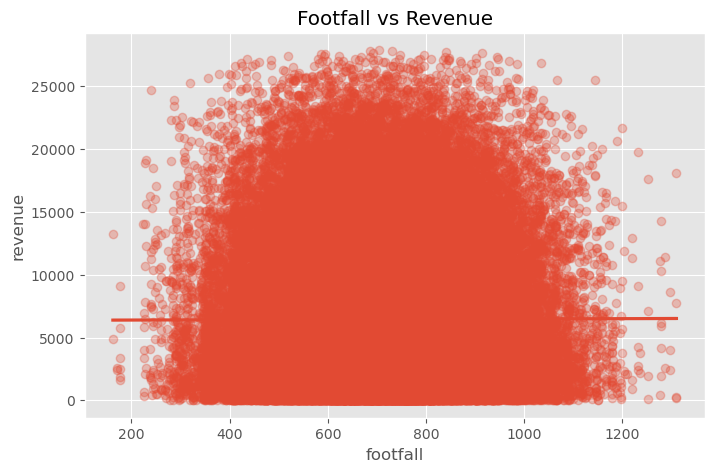

In [30]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=sales,
    x="footfall",
    y="revenue",
    scatter_kws={"alpha":0.3}
)

plt.title("Footfall vs Revenue")
plt.show()

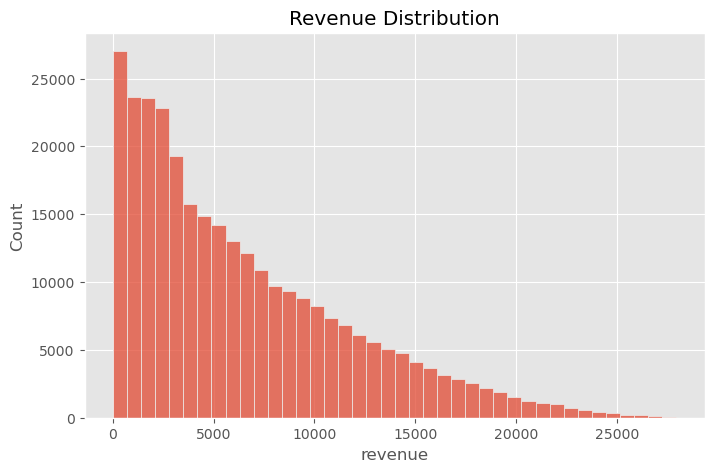

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    sales["revenue"],
    bins=40
)

plt.title("Revenue Distribution")
plt.show()